# 03 — Diseño del experimento

## Objetivo

En este notebook se define y valida el protocolo experimental utilizado para comparar métodos tradicionales de Desarrollo con modelos predictivos aplicados a los tres escenarios simulados de Loss Incurred.

El objetivo de esta fase no es determinar qué metodología obtiene mejores resultados, sino fijar **antes del backtesting**:

- las fechas históricas de valuación;
- el horizonte de madurez de cada escenario;
- la definición del target;
- las reglas de elegibilidad para entrenamiento y evaluación;
- las alternativas del Método de Desarrollo;
- la estructura del dataset supervisado;
- las variables disponibles para los modelos predictivos;
- el mínimo de información requerido para ajustar ML;
- las métricas y reglas de comparación.

Esta separación es importante para evitar que las decisiones metodológicas se modifiquen después de observar los resultados.

---

## Principio temporal

Para cada fecha histórica de valuación, los métodos solo podrán utilizar información que habría estado disponible hasta dicha fecha.

Aunque la simulación permite observar actualmente toda la trayectoria de desarrollo, el backtesting reconstruirá cada valuación histórica como si el futuro todavía fuera desconocido.

Por tanto, se distingue entre:

1. **información observable en la valuación**;
2. **target futuro utilizado posteriormente para evaluar la predicción**;
3. **información futura prohibida durante la construcción de la predicción**.

---

## Implementación reproducible

Las decisiones metodológicas congeladas en esta fase se centralizan en `src/experiment`.  
Este notebook **no redefine** la configuración del experimento: importa las constantes, reglas de elegibilidad y validaciones desde los módulos del proyecto y se concentra en documentarlas, verificarlas y presentar sus implicaciones.


### Imports

In [26]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PROJECT_ROOT


WindowsPath('c:/Users/derec/Desktop/Proyectos/Modelado_Reservas_ML_vs_metodos_Actuariales')

In [27]:
import sys

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.experiment import (
    BACKTEST_END,
    BACKTEST_START,
    DEVELOPMENT_ALTERNATIVES,
    DEV_BANDS,
    DEV_M,
    FINAL_PERIOD,
    GLM_FEATURES,
    MIN_MATURE_COHORTS_ML,
    TREE_FEATURES,
    VALUATION_PERIODS,
    build_eligibility_grid,
    first_possible_ml_valuation,
    months_between,
    validate_eligibility_frame,
    validate_experiment_config,
)

from src.experiment.config import (
    FIRST_ACCIDENT_PERIOD,
    FORBIDDEN_PREDICTORS,
    RELATIVE_SELECTION_THRESHOLD,
)


## 1. Configuración temporal

Los horizontes de madurez se mantienen fijos según el diseño original de la simulación:

| Escenario | `dev_M` |
|---|---:|
| Creciente | 60 meses |
| Decreciente | 48 meses |
| Mixto | 48 meses |

Estos horizontes no serán recalibrados durante el experimento.

La última fecha disponible en las bases simuladas es diciembre de 2025. Esta fecha se reserva como cierre del experimento y como límite máximo para observar los targets utilizados en el backtesting.

Las valuaciones históricas se realizarán mensualmente entre enero de 2020 y noviembre de 2025.

### Configuración congelada e importada desde `src.experiment`

La configuración temporal y metodológica se mantiene en `src/experiment/config.py`, que actúa como **fuente única de verdad** para el notebook, los tests y el backtesting posterior.

En esta sección únicamente se inspecciona y valida dicha configuración; no se redefinen constantes localmente.


In [28]:
experiment_config = pd.DataFrame(
    {
        "scenario": list(DEV_M.keys()),
        "dev_M": list(DEV_M.values()),
    }
)

print(f"Backtesting: {BACKTEST_START} a {BACKTEST_END}")
print(f"Cierre del experimento: {FINAL_PERIOD}")
print(f"Número de valuaciones: {len(VALUATION_PERIODS)}")
print(f"Mínimo de cohortes maduras para ML: {MIN_MATURE_COHORTS_ML}")

experiment_config


Backtesting: 2020-01 a 2025-11
Cierre del experimento: 2025-12
Número de valuaciones: 71
Mínimo de cohortes maduras para ML: 12


,scenario,dev_M
0,creciente,60
1,decreciente,48
2,mixto,48


In [29]:
validate_experiment_config()

print("=" * 60)
print("CONFIGURACIÓN DEL EXPERIMENTO VALIDADA")
print("=" * 60)
print("Las reglas importadas desde src.experiment son consistentes.")


CONFIGURACIÓN DEL EXPERIMENTO VALIDADA
Las reglas importadas desde src.experiment son consistentes.


## 2. Unidad de observación del backtesting

Una observación histórica queda definida por:

$$
(\text{scenario},
\text{valuation period},
\text{accident period},
\text{latest dev month})
$$

Para un período de ocurrencia $a$ y una valuación histórica $t$, la edad de desarrollo observable es:

$$
d=t-a
$$

expresada en meses.

El objetivo del experimento es estimar el monto acumulado que alcanzará dicha cohorte en su horizonte de madurez:

$$
Y_a=L_{a,M}.
$$

Por tanto, el target de los modelos predictivos será directamente el **monto acumulado a madurez**.

## 3. Fecha de revelación del target

Para cada período de ocurrencia $a$, el target se considera conocido cuando alcanza el horizonte de madurez $M$:

$$
\text{target period}=a+M.
$$

Una cohorte puede formar parte del conjunto de entrenamiento en una valuación histórica $t$ únicamente cuando:

$$
a+M\leq t.
$$

En cambio, una observación de backtesting debe encontrarse todavía inmadura en $t$:

$$
0\leq d<M,
$$

pero su target debe haberse revelado antes del cierre del experimento:

$$
a+M\leq 2025\text{-}12.
$$

### cobertura de edades

In [30]:
# La función months_between se importa desde src.experiment.eligibility.
# Se verifica aquí su comportamiento con un ejemplo simple.

example_start = pd.Period("2020-01", freq="M")
example_end = pd.Period("2020-07", freq="M")

months_between(example_start, example_end)


6

Test

In [31]:
assert months_between(
    pd.Period("2020-01", freq="M"),
    pd.Period("2020-07", freq="M"),
) == 6

print("Función temporal `months_between` validada.")


Función temporal `months_between` validada.


### Último cohorte evaluable

In [32]:
evaluable_limits = pd.DataFrame(
    [
        {
            "scenario": scenario,
            "dev_M": dev_m,
            "final_period": FINAL_PERIOD,
            "latest_evaluable_accident_period": FINAL_PERIOD - dev_m,
        }
        for scenario, dev_m in DEV_M.items()
    ]
)

evaluable_limits


,scenario,dev_M,final_period,latest_evaluable_accident_period
0,creciente,60,2025-12,2020-12
1,decreciente,48,2025-12,2021-12
2,mixto,48,2025-12,2021-12


In [33]:
expected_latest_evaluable = {
    "creciente": pd.Period("2020-12", freq="M"),
    "decreciente": pd.Period("2021-12", freq="M"),
    "mixto": pd.Period("2021-12", freq="M"),
}

observed_latest_evaluable = (
    evaluable_limits
    .set_index("scenario")["latest_evaluable_accident_period"]
    .to_dict()
)

assert observed_latest_evaluable == expected_latest_evaluable

print("Límites de evaluación validados.")


Límites de evaluación validados.


### Cobertura del diseño anterior

El diseño preliminar utilizaba junio de 2022 como primera valuación histórica.

Esto provocaba que las cohortes cuyo target podía observarse antes de diciembre de 2025 ya hubieran alcanzado varios meses de desarrollo cuando comenzaba el backtesting.

Como consecuencia, las edades más jóvenes nunca eran evaluadas.

In [34]:
OLD_BACKTEST_START = pd.Period("2022-06", freq="M")

old_coverage = []

for scenario, dev_m in DEV_M.items():
    latest_evaluable_ap = FINAL_PERIOD - dev_m

    min_dev = months_between(
        latest_evaluable_ap,
        OLD_BACKTEST_START,
    )

    old_coverage.append(
        {
            "scenario": scenario,
            "dev_M": dev_m,
            "old_first_valuation": OLD_BACKTEST_START,
            "latest_evaluable_accident_period": latest_evaluable_ap,
            "minimum_tested_dev_month": min_dev,
        }
    )

old_coverage = pd.DataFrame(old_coverage)

old_coverage


,scenario,dev_M,old_first_valuation,latest_evaluable_accident_period,minimum_tested_dev_month
0,creciente,60,2022-06,2020-12,18
1,decreciente,48,2022-06,2021-12,6
2,mixto,48,2022-06,2021-12,6


In [35]:
expected_old_minimum_age = {
    "creciente": 18,
    "decreciente": 6,
    "mixto": 6,
}

assert (
    old_coverage
    .set_index("scenario")["minimum_tested_dev_month"]
    .to_dict()
    == expected_old_minimum_age
)

print("Se reprodujo correctamente la limitación del diseño anterior.")


Se reprodujo correctamente la limitación del diseño anterior.


### Rediseño de las valuaciones

Para eliminar esta exclusión estructural se adelanta la primera valuación a enero de 2020.

Esta fecha coincide con el momento en el que la primera cohorte del escenario creciente alcanza 60 meses de desarrollo.

El cambio permite incorporar observaciones desde edad de desarrollo cero, aunque el número de observaciones disponible no será uniforme entre edades.

La menor representación de las edades jóvenes se documentará posteriormente mediante métricas específicas por bandas de desarrollo.

In [36]:
ACCIDENT_PERIODS = pd.period_range(
    FIRST_ACCIDENT_PERIOD,
    FINAL_PERIOD,
    freq="M",
)

eligibility_frames = []

for scenario in DEV_M:
    grid = build_eligibility_grid(
        accident_periods=ACCIDENT_PERIODS,
        scenario=scenario,
        valuation_periods=VALUATION_PERIODS,
        final_period=FINAL_PERIOD,
    )

    # La misma validación que protegerá el backtesting posterior.
    validate_eligibility_frame(grid)
    eligibility_frames.append(grid)

eligibility = pd.concat(
    eligibility_frames,
    ignore_index=True,
)

coverage_by_age = (
    eligibility
    .loc[eligibility["is_backtest_evaluable"]]
    .groupby(
        ["scenario", "latest_dev_month"],
        as_index=False,
    )
    .agg(
        n_observations=("accident_period", "size"),
        n_valuation_periods=("valuation_period", "nunique"),
        n_accident_periods=("accident_period", "nunique"),
        first_evaluable_valuation=("valuation_period", "min"),
        last_evaluable_valuation=("valuation_period", "max"),
    )
    .rename(columns={"latest_dev_month": "dev_month"})
)

coverage_by_age.head(15)


,scenario,dev_month,n_observations,n_valuation_periods,n_accident_periods,first_evaluable_valuation,last_evaluable_valuation
0,creciente,0,12,12,12,2020-01,2020-12
1,creciente,1,13,13,13,2020-01,2021-01
2,creciente,2,14,14,14,2020-01,2021-02
3,creciente,3,15,15,15,2020-01,2021-03
4,creciente,4,16,16,16,2020-01,2021-04
5,creciente,5,17,17,17,2020-01,2021-05
6,creciente,6,18,18,18,2020-01,2021-06
7,creciente,7,19,19,19,2020-01,2021-07
8,creciente,8,20,20,20,2020-01,2021-08
9,creciente,9,21,21,21,2020-01,2021-09


In [37]:
for scenario, dev_m in DEV_M.items():
    observed_ages = set(
        coverage_by_age
        .loc[coverage_by_age["scenario"] == scenario, "dev_month"]
        .unique()
    )

    assert observed_ages == set(range(dev_m))

print("Todas las edades de desarrollo están representadas en el backtesting.")


Todas las edades de desarrollo están representadas en el backtesting.


### Visualización de cobertura

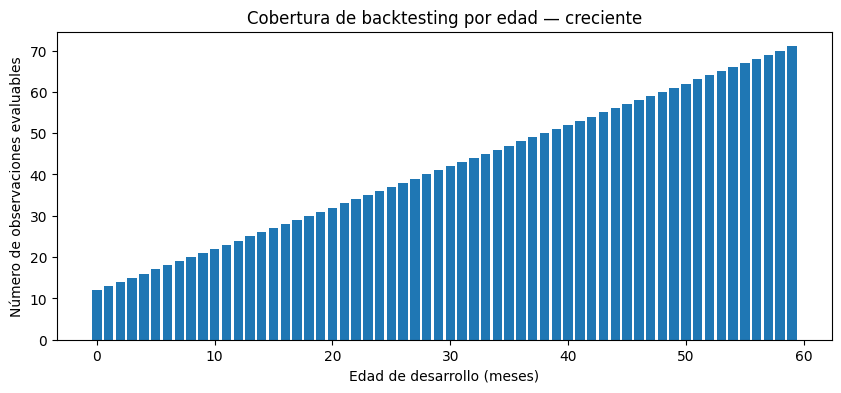

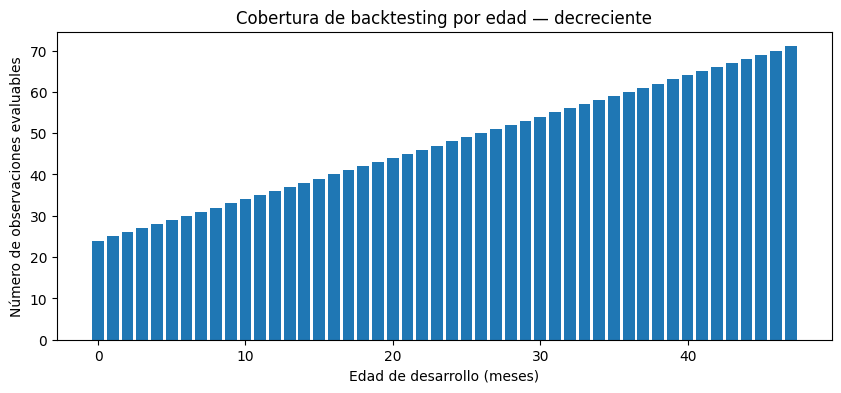

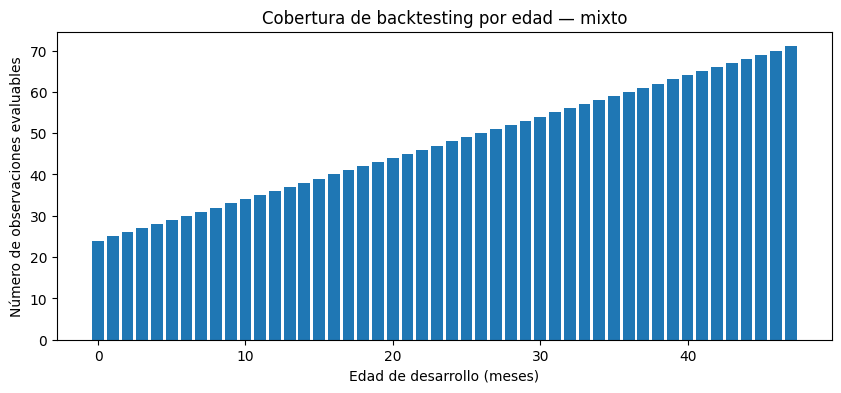

In [38]:
for scenario in DEV_M:
    subset = coverage_by_age.loc[
        coverage_by_age["scenario"] == scenario
    ]

    fig, ax = plt.subplots(figsize=(10, 4))

    ax.bar(
        subset["dev_month"],
        subset["n_observations"],
    )

    ax.set_title(
        f"Cobertura de backtesting por edad — {scenario}"
    )
    ax.set_xlabel("Edad de desarrollo (meses)")
    ax.set_ylabel("Número de observaciones evaluables")

    plt.show()


## 4. Reglas de elegibilidad

Para cada combinación de período de ocurrencia y valuación histórica se calculan:

- `latest_dev_month`;
- `target_period`;
- `is_mature_at_valuation`;
- `is_target_revealed_by_end`;
- `is_backtest_evaluable`.

Una observación pertenece al backtesting cuando:

$$
0\leq d<M
$$

y:

$$
\text{target period}\leq\text{final period}.
$$

Los modelos predictivos, en cambio, solo pueden entrenarse con cohortes cuyo target ya se conocía en la fecha histórica de ajuste:

$$
\text{target period}\leq\text{valuation period}.
$$

In [39]:
development_catalog = pd.DataFrame(
    DEVELOPMENT_ALTERNATIVES,
    columns=[
        "aggregation",
        "window",
        "exclusion",
    ],
)

development_catalog["method_name"] = (
    development_catalog["aggregation"].astype(str)
    + "_"
    + development_catalog["window"].astype(str)
    + "_"
    + development_catalog["exclusion"]
)

development_catalog


,aggregation,window,exclusion,method_name
0,S,24,none,S_24_none
1,S,24,minmax,S_24_minmax
2,S,24,std2,S_24_std2
3,S,all,none,S_all_none
4,S,all,minmax,S_all_minmax
5,S,all,std2,S_all_std2
6,VW,24,none,VW_24_none
7,VW,24,minmax,VW_24_minmax
8,VW,24,std2,VW_24_std2
9,VW,all,none,VW_all_none


In [40]:
assert len(development_catalog) == len(DEVELOPMENT_ALTERNATIVES)
assert development_catalog["method_name"].is_unique

print(
    f"Catálogo validado: {len(development_catalog)} "
    "alternativas de Desarrollo."
)


Catálogo validado: 21 alternativas de Desarrollo.


## 5. Alternativas del Método de Desarrollo

Se compararán 21 especificaciones definidas antes del backtesting.

Las 18 alternativas base combinan:

- tres métodos de agregación:
  - promedio simple;
  - ponderado por volumen;
  - mediana;

- dos ventanas:
  - 24 períodos de ocurrencia;
  - toda la historia disponible;

- tres reglas de exclusión:
  - ninguna;
  - exclusión del mínimo y máximo;
  - exclusión de observaciones fuera de ±2 desviaciones estándar.

Adicionalmente se incorporan tres ventanas para estudiar de forma aislada el efecto de la longitud de la historia:

- 6 meses;
- 12 meses;
- 36 meses.

En estas tres alternativas se mantiene fijo el promedio ponderado por volumen y no se aplican exclusiones.

De esta forma, las diferencias observadas pueden atribuirse principalmente al tamaño de la ventana histórica.

## 6. Dataset supervisado

Una fila del dataset predictivo representa una cohorte observada a una determinada edad de desarrollo:

$$
X_{a,d}\rightarrow L_{a,M}.
$$

Durante el entrenamiento, una cohorte madura puede generar múltiples snapshots:

$$
d=0,1,\ldots,M-1.
$$

Todos comparten el mismo target $L_{a,M}$, pero contienen diferentes cantidades de información observable.

Durante el backtesting, cada cohorte genera una sola observación por fecha histórica de valuación: aquella correspondiente a la edad que realmente tenía en ese momento.

In [41]:
feature_catalog = pd.DataFrame(
    {
        "model_family": (
            ["GLM"] * len(GLM_FEATURES)
            + ["Árboles"] * len(TREE_FEATURES)
        ),
        "feature": (
            list(GLM_FEATURES)
            + list(TREE_FEATURES)
        ),
    }
)

print(f"Features GLM: {len(GLM_FEATURES)}")
print(f"Features árboles: {len(TREE_FEATURES)}")

feature_catalog


Features GLM: 7
Features árboles: 10


,model_family,feature
0,GLM,log_observed_amount
1,GLM,dev_month
2,GLM,dev_month_sq
3,GLM,accident_time_idx
4,GLM,accident_month_sin
5,GLM,accident_month_cos
6,GLM,delta_1m
7,Árboles,observed_amount
8,Árboles,dev_month
9,Árboles,accident_time_idx


### Selección de variables

Los tres modelos utilizarán la misma fuente de información histórica, aunque no necesariamente las mismas transformaciones.

El GLM se mantiene deliberadamente parsimonioso para reducir problemas de multicolinealidad y preservar interpretabilidad.

Su especificación utiliza principalmente:

- monto observado;
- edad de desarrollo;
- tendencia temporal;
- estacionalidad;
- último movimiento mensual.

Random Forest y XGBoost pueden incorporar adicionalmente medidas recientes de tendencia y dispersión, ya que los modelos basados en árboles son menos sensibles a la multicolinealidad desde el punto de vista de estimación.

En ningún modelo se utilizarán variables calculadas con información posterior al snapshot.

### Variables prohibidas

In [42]:
pd.DataFrame(
    {
        "forbidden_predictor": list(FORBIDDEN_PREDICTORS)
    }
)


,forbidden_predictor
0,target_amount
1,target_period
2,is_mature_at_valuation
3,is_target_revealed_by_end


In [43]:
glm_forbidden = set(GLM_FEATURES).intersection(FORBIDDEN_PREDICTORS)
tree_forbidden = set(TREE_FEATURES).intersection(FORBIDDEN_PREDICTORS)

assert not glm_forbidden
assert not tree_forbidden

print(
    "No se detectaron variables explícitamente futuras "
    "entre los predictores configurados."
)


No se detectaron variables explícitamente futuras entre los predictores configurados.


## 7. Suficiencia mínima para modelos predictivos

La generación de múltiples snapshots de una misma cohorte aumenta el número de filas del dataset, pero no aumenta en la misma proporción el número de experiencias independientes.

Por este motivo, la suficiencia del entrenamiento no se medirá únicamente mediante el número de filas.

Se exigirá un mínimo de:

$$
12
$$

períodos de ocurrencia maduros distintos antes de ajustar GLM, Random Forest o XGBoost.

El valor representa aproximadamente un ciclo anual completo de cohortes mensuales.

Cuando este requisito no se cumpla, la valuación se conservará en el experimento, pero se registrará como:

`insufficient_training_history`

para los modelos predictivos.

### Empezar ML

In [44]:
twelfth_cohort = (
    FIRST_ACCIDENT_PERIOD
    + MIN_MATURE_COHORTS_ML
    - 1
)

ml_start_table = pd.DataFrame(
    [
        {
            "scenario": scenario,
            "dev_M": dev_m,
            "minimum_mature_cohorts": MIN_MATURE_COHORTS_ML,
            "twelfth_accident_period": twelfth_cohort,
            "first_possible_ml_valuation": first_possible_ml_valuation(
                scenario
            ),
            "available_at_backtest_start": (
                first_possible_ml_valuation(scenario)
                <= BACKTEST_START
            ),
        }
        for scenario, dev_m in DEV_M.items()
    ]
)

ml_start_table


,scenario,dev_M,minimum_mature_cohorts,twelfth_accident_period,first_possible_ml_valuation,available_at_backtest_start
0,creciente,60,12,2015-12,2020-12,False
1,decreciente,48,12,2015-12,2019-12,True
2,mixto,48,12,2015-12,2019-12,True


## 8. Protocolo de evaluación

Cada predicción será comparada contra el monto real a madurez mediante:

### MAE

$$
MAE=
\frac{1}{n}
\sum_i
|\hat Y_i-Y_i|.
$$

### RMSE

$$
RMSE=
\sqrt{
\frac{1}{n}
\sum_i
(\hat Y_i-Y_i)^2
}.
$$

### MAPE

$$
MAPE=
\frac{1}{n}
\sum_i
\left|
\frac{\hat Y_i-Y_i}{Y_i}
\right|.
$$

### Sesgo relativo

$$
Bias=
\frac{
\sum_i(\hat Y_i-Y_i)
}{
\sum_iY_i
}.
$$

MAPE será la métrica primaria de comparación.

MAE y RMSE se utilizarán como métricas complementarias y el sesgo relativo será un criterio explícito de control y desempate.

In [45]:
band_rows = []

for dev_m, bands in DEV_BANDS.items():
    for lower, upper in bands:
        band_rows.append(
            {
                "dev_M": dev_m,
                "band": f"{lower}-{upper}",
                "lower": lower,
                "upper": upper,
            }
        )

development_band_catalog = pd.DataFrame(band_rows)

development_band_catalog


,dev_M,band,lower,upper
0,60,0-5,0,5
1,60,6-11,6,11
2,60,12-23,12,23
3,60,24-35,24,35
4,60,36-47,36,47
5,60,48-59,48,59
6,48,0-5,0,5
7,48,6-11,6,11
8,48,12-23,12,23
9,48,24-35,24,35


In [46]:
# `validate_experiment_config()` incluye la validación de que
# las bandas cubran exactamente 0,...,dev_M-1 sin huecos.
validate_experiment_config()

print("Bandas de desarrollo importadas y validadas.")


Bandas de desarrollo importadas y validadas.


## 9. Regla de selección

Una vez ejecutado el backtesting, se identificará el menor MAPE observado dentro del conjunto comparable:

$$
MAPE_{\min}.
$$

Se considerarán competitivas las metodologías cuyo MAPE cumpla:

$$
MAPE_m
\leq
1.05\,MAPE_{\min}.
$$

Por tanto, el 5 % corresponde a una tolerancia **relativa respecto al mejor MAPE**, no a cinco puntos porcentuales.

Entre las alternativas que permanezcan dentro de este rango se utilizarán, en orden:

1. menor sesgo absoluto;
2. comportamiento razonable por bandas de desarrollo;
3. estabilidad temporal;
4. simplicidad metodológica.

Las decisiones se realizarán por escenario y no se supondrá la existencia de una metodología universalmente superior.

### Resumen del experimento

In [47]:
experiment_summary = pd.DataFrame(
    {
        "parameter": [
            "Primera valuación",
            "Última valuación de backtesting",
            "Cierre del experimento",
            "Frecuencia",
            "Target",
            "Alternativas de Desarrollo",
            "Modelos predictivos",
            "Mínimo cohortes maduras ML",
            "Métrica primaria",
            "Umbral competitivo",
        ],
        "value": [
            str(BACKTEST_START),
            str(BACKTEST_END),
            str(FINAL_PERIOD),
            "Mensual",
            "Monto acumulado a dev_M",
            len(DEVELOPMENT_ALTERNATIVES),
            "GLM Gamma/log, Random Forest, XGBoost",
            MIN_MATURE_COHORTS_ML,
            "MAPE",
            f"{RELATIVE_SELECTION_THRESHOLD:.0%} relativo al mejor MAPE",
        ],
    }
)

experiment_summary


,parameter,value
0,Primera valuación,2020-01
1,Última valuación de backtesting,2025-11
2,Cierre del experimento,2025-12
3,Frecuencia,Mensual
4,Target,Monto acumulado a dev_M
5,Alternativas de Desarrollo,21
6,Modelos predictivos,"GLM Gamma/log, Random Forest, XGBoost"
7,Mínimo cohortes maduras ML,12
8,Métrica primaria,MAPE
9,Umbral competitivo,5% relativo al mejor MAPE


In [48]:
# Validación central de configuración.
validate_experiment_config()

# Validación de elegibilidad sobre la cuadrícula utilizada en el notebook.
for scenario in DEV_M:
    scenario_grid = eligibility.loc[
        eligibility["scenario"] == scenario
    ].copy()

    validate_eligibility_frame(scenario_grid)

# Validación específica de la cobertura completa por edades.
for scenario, dev_m in DEV_M.items():
    observed_ages = set(
        coverage_by_age
        .loc[coverage_by_age["scenario"] == scenario, "dev_month"]
    )

    assert observed_ages == set(range(dev_m))

# Validación de unicidad del catálogo mostrado.
assert development_catalog["method_name"].is_unique

print("=" * 60)
print("DISEÑO EXPERIMENTAL VALIDADO")
print("=" * 60)
print()
print("✓ Configuración central de src.experiment consistente")
print("✓ Reglas de elegibilidad temporal validadas")
print("✓ Todas las edades de desarrollo están representadas")
print(f"✓ {len(DEVELOPMENT_ALTERNATIVES)} alternativas de Desarrollo definidas")
print("✓ Target definido como monto a madurez")
print("✓ Features de ML importadas desde la configuración")
print(f"✓ Mínimo de cohortes maduras para ML: {MIN_MATURE_COHORTS_ML}")
print(
    "✓ Umbral competitivo: "
    f"{RELATIVE_SELECTION_THRESHOLD:.0%} relativo al mejor MAPE"
)


DISEÑO EXPERIMENTAL VALIDADO

✓ Configuración central de src.experiment consistente
✓ Reglas de elegibilidad temporal validadas
✓ Todas las edades de desarrollo están representadas
✓ 21 alternativas de Desarrollo definidas
✓ Target definido como monto a madurez
✓ Features de ML importadas desde la configuración
✓ Mínimo de cohortes maduras para ML: 12
✓ Umbral competitivo: 5% relativo al mejor MAPE


## Conclusiones

El protocolo experimental queda definido antes de ejecutar cualquier comparación de desempeño.

La principal modificación respecto al diseño preliminar consiste en adelantar el inicio del backtesting a enero de 2020. Esto permite evaluar explícitamente las edades jóvenes que quedaban excluidas cuando las valuaciones comenzaban en junio de 2022.

El diseño distingue de manera estricta entre:

- información disponible en cada snapshot;
- cohortes con target conocido para entrenamiento;
- cohortes inmaduras utilizadas para backtesting;
- target revelado posteriormente para evaluación.

Además, se establecieron previamente:

- 21 alternativas del Método de Desarrollo;
- tres metodologías predictivas;
- las variables permitidas;
- un mínimo de 12 cohortes maduras para ML;
- las métricas de evaluación;
- las bandas de desarrollo;
- la regla relativa del 5 %;
- los criterios de desempate.

Con estas reglas congeladas, la siguiente fase puede concentrarse en ejecutar el backtesting sin modificar el protocolo en función de los resultados observados.